### Deep Learning  
Deep learning is a subset of machine learning that uses **artificial neural networks (ANNs)** to analyze and interpret data.  

---

### Neurons  
- The **neuron** is the fundamental unit of computation in an ANN.  
- It **receives inputs**, performs a **computation**, and produces an **output**.  
- Neurons are inspired by **biological neurons** in our brains and are designed to mimic their functionality.  

### Weight
- Each **connection** between neurons in an Ann is associated with a **weight**. The **weight** determines the **strength** or **importance of the connection**.

### Activation Function
- The activation function of a neuron determines the **output value** based on the **weighted sum of its inputs**. (Sigmoid, ReLU)

### Bias
- A **bias term** is an additional input to a neuron that helps **adjust the output**. It provides the neuron with a certain degree of flexibility and allows it ot make predictions even when all input values are zeron.

### Layers
- **Input Layer**: It receives and passes **input data** to the subsequent layers. It does not perform any computations.
- **Output Layer**: It produces the final **output of the network** based on the **processed information** from the hidden layers.
- **Hidden Layer**: It is optional and process and transform inputs from network's weights and activation functions.

### Multi-Layer Perceptron
- **MLP** is a feedforward neural network consisting of multiple layers. MLPs can approximate any continuous function, theryby can be used for to create complex decision boundaries that separate data points belonging to different classes.

### -------------------------------------------------------------------------------------------------
- You will learn to separate points with different labels (0 or 1) using Multilayer Perceptron.
- **Action**
- You will change the number of neurons in a layer using an interactive slider and watch the effect on the separation / decision boundary.
  

In [33]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.neural_network import MLPClassifier
import ipywidgets as widgets
from IPython.display import display, clear_output


interactive(children=(IntSlider(value=4, continuous_update=False, description='Hidden Layer Size:', max=10, mi…

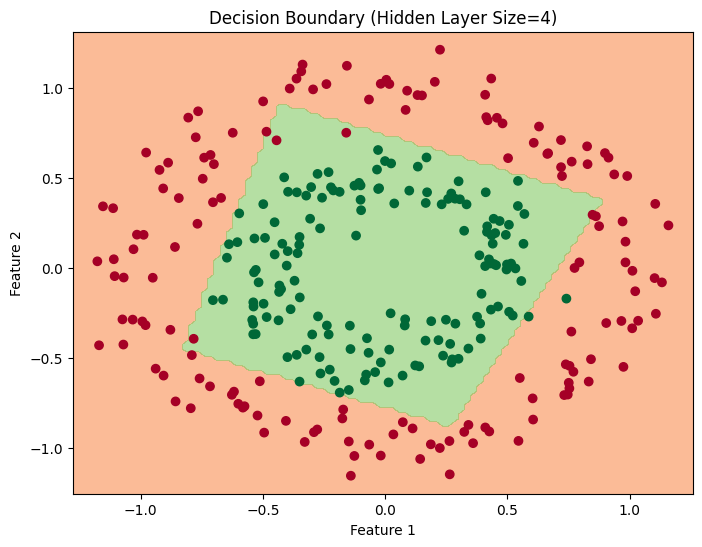

In [44]:
# --- KEY CHANGE 1: Create the figure and axes ONCE, outside the function ---
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Function to update the plot
def update_plot(hidden_layer_size):
    # Generate synthetic data# Number of neurons in the hidden layer of the neural network as input.
    # Think of plotting 300 dots, some forming an inner circle, some forming an outer circle.
    X, y = make_circles(n_samples=300, noise=0.1, factor=0.5, random_state=0)

    # Create a multi-layer perceptron (MLP) classifier
    # This defines the "brain" that will learn to separate the circles.
    clf = MLPClassifier(hidden_layer_sizes=(hidden_layer_size,), activation='relu',
                        max_iter=3000, random_state=1)
    # Fit the classifier to the data
    # Trains the neural network on the circle dataset (X and Y)
    clf.fit(X, y)

    # Create a grid of points for visualization
    # Creates evenly spaced values for the x-axis and y-axis.
    #   X[:,0] → Take all rows (:) of the first column (0).
    # 👉 This gives all the x-coordinates of your dataset.

    # X[:,0].min() → Find the smallest x value in the dataset.
    # X[:,0].max() → Find the largest x value in the dataset.

    # X[:,0].min() - 0.1 → Shift the lower bound a little left (extra space).
    # X[:,0].max() + 0.1 → Shift the upper bound a little right (extra space).

    # 100 → Number of equally spaced points to generate between the min and max values.

    # 📌 Result: x_vals is a list of 100 evenly spaced values from a little below the smallest x
    #      to a little above the largest x.
    x_vals = np.linspace(X[:,0].min() - 0.1, X[:,0].max() + 0.1, 100)
    y_vals = np.linspace(X[:,1].min() - 0.1, X[:,1].max() + 0.1, 100)
    # Creates a grid of points
    X_plane, Y_plane = np.meshgrid(x_vals, y_vals)
    # Flattens the grid into a list of points (ravel makes 2D into 1D)
    # For each of these points, predict: are you inner circle (0) or outer circle (1)?
    grid_points = np.column_stack((X_plane.ravel(), Y_plane.ravel()))

    # Predict class labels for the grid points across the 2D plane.
    Z = clf.predict(grid_points)
    Z = Z.reshape(X_plane.shape)

    # --- KEY CHANGE 2: Clear the AXES, not the whole figure ---
    ax.clear()

    # --- KEY CHANGE 3: Plot on the axes object (ax) instead of plt ---
    ax.contourf(X_plane, Y_plane, Z, levels=[-0.5, 0.5, 1.5],
                cmap=plt.cm.RdYlGn, alpha=0.6)
    ax.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.RdYlGn)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.set_title(f'Decision Boundary (Hidden Layer Size={hidden_layer_size})')
    
    # --- KEY CHANGE 4: Redraw the canvas, no plt.show() needed ---
    fig.canvas.draw_idle()


# --- NEW, SIMPLER WAY TO CREATE WIDGETS AND LINK THEM ---

# 1. Create the slider widget
hidden_layer_size_slider = widgets.IntSlider(
    value=4, min=1, max=10, step=1, description='Hidden Layer Size:', continuous_update=False
)

# 2. Create the interactive object
# This automatically calls update_plot(hidden_layer_size=slider.value) whenever the slider changes
interactive_plot = widgets.interactive(update_plot, hidden_layer_size=hidden_layer_size_slider)

# 3. Display the interactive object (it shows both the controls and the output)
display(interactive_plot)
